Module 2 - Data Preprocessing & Feature Engineering

Objective

The objective of this phase is to transform the raw Lending Club dataset into a clean and structured dataset suitable for credit risk modelling.

Unlike the exploratory analysis performed previously, this phase focuses on preparing the data for machine learning by removing leakage variables, handling missing values, treating outliers, engineering new features, and building a reusable preprocessing pipeline.

The preprocessing steps will be implemented carefully to avoid data leakage and to ensure the same transformations can later be applied during model deployment.

Preprocessing Roadmap :-

The preprocessing pipeline will be developed in the following order:

1. Load modelling dataset
2. Review current feature set
3. Identify leakage variables
4. Remove identifier columns
5. Handle missing values
6. Handle outliers
7. Feature engineering
8. Feature encoding
9. Feature scaling
10. Train-test split
11. Build reusable preprocessing pipeline

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [4]:
df = pd.read_csv(
    "../data/raw/accepted_2007_to_2018Q4.csv",
    low_memory=False
)

print("Dataset Loaded Successfully")



Dataset Loaded Successfully


In [5]:
risk_df = df[
    df["loan_status"].isin(
        ["Fully Paid", "Charged Off"]
    )
].copy()

risk_df["target"] = np.where(
    risk_df["loan_status"] == "Charged Off",
    1,
    0
)

print(risk_df.shape)

risk_df["target"].value_counts()

(1345310, 152)


target
0    1076751
1     268559
Name: count, dtype: int64

Feature Audit

Before preprocessing begins, all available variables are reviewed to identify:

- Identifier variables
- Target leakage variables
- High missing value variables
- Business relevant features
- Features requiring transformation

Only after this review will features be removed from the modelling dataset.

In [6]:
feature_audit = pd.DataFrame({
    "Feature": risk_df.columns,
    "Data Type": risk_df.dtypes.values,
    "Missing Values": risk_df.isnull().sum().values,
    "Missing (%)": (
        risk_df.isnull().mean()*100
    ).values
})

feature_audit.sort_values(
    by="Missing (%)",
    ascending=False
).head(50)

,Feature,Data Type,Missing Values,Missing (%)
1,member_id,float64,1345310,100.000000
49,next_pymnt_d,str,1345310,100.000000
140,orig_projected_additional_accrued_interest,float64,1341551,99.720585
133,hardship_amount,float64,1339556,99.572292
142,hardship_last_payment_amount,float64,1339556,99.572292
137,hardship_length,float64,1339556,99.572292
131,hardship_status,str,1339556,99.572292
130,hardship_reason,str,1339556,99.572292
132,deferral_term,float64,1339556,99.572292
134,hardship_start_date,str,1339556,99.572292


In [7]:
feature_audit.to_csv(
    "../reports/feature_audit.csv",
    index=False
)

print("Feature audit exported successfully.")

Feature audit exported successfully.


Feature Categorization

Before removing any variables, the features are categorized based on their business relevance and their suitability for predictive modelling.

The categories include:

- Identifier Features
- Target Leakage Features
- Joint Application Features
- High Missing Features
- Features to Retain
- Features Requiring Further Investigation

This approach ensures that feature removal decisions are based on both business understanding and data quality rather than only missing value percentages.

In [8]:
identifier_columns = [
    "id",
    "member_id",
    "url"
]

identifier_columns

['id', 'member_id', 'url']

In [9]:
leakage_columns = [

    "next_pymnt_d",

    "hardship_type",
    "hardship_reason",
    "hardship_status",
    "deferral_term",
    "hardship_amount",
    "hardship_start_date",
    "hardship_end_date",
    "payment_plan_start_date",
    "hardship_length",
    "hardship_dpd",
    "hardship_loan_status",
    "hardship_payoff_balance_amount",
    "hardship_last_payment_amount",
    "orig_projected_additional_accrued_interest",

    "debt_settlement_flag_date",
    "settlement_status",
    "settlement_date",
    "settlement_amount",
    "settlement_percentage",
    "settlement_term"
]

len(leakage_columns)

21

In [10]:
joint_application_columns = [

    "annual_inc_joint",
    "verification_status_joint",
    "dti_joint",

    "revol_bal_joint",

    "sec_app_fico_range_low",
    "sec_app_fico_range_high",
    "sec_app_earliest_cr_line",

    "sec_app_inq_last_6mths",
    "sec_app_mort_acc",
    "sec_app_open_acc",
    "sec_app_revol_util",
    "sec_app_open_act_il",
    "sec_app_num_rev_accts",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_mths_since_last_major_derog"

]

len(joint_application_columns)

16

In [11]:
print("Identifier Columns :", len(identifier_columns))
print("Leakage Columns :", len(leakage_columns))
print("Joint Application Columns :", len(joint_application_columns))

Identifier Columns : 3
Leakage Columns : 21
Joint Application Columns : 16


Initial Feature Removal Strategy

Based on the feature audit, three groups of variables have been identified for removal during preprocessing.

1. Identifier variables (`id`, `member_id`, `url`) do not contain predictive information and are only used for record identification.

2. Hardship, settlement and future payment related variables contain information that becomes available only after loan issuance. Including these variables would introduce target leakage and artificially inflate model performance.

3. Joint application variables have more than 98% missing values because the majority of loans are single-applicant loans. Retaining these variables would add unnecessary complexity while contributing little predictive value.

In [12]:
all_columns_to_remove = (
    identifier_columns
    + leakage_columns
    + joint_application_columns
)

missing_columns = [
    col for col in all_columns_to_remove
    if col not in risk_df.columns
]

print("Total Columns Planned for Removal :", len(all_columns_to_remove))
print("Columns Not Found :", len(missing_columns))

if missing_columns:
    print(missing_columns)
else:
    print("All columns exist.")

Total Columns Planned for Removal : 40
Columns Not Found : 0
All columns exist.


Dataset Before Feature Removal

The initial modelling dataset is recorded before removing non-predictive and leakage variables.
Recording the dataset dimensions before each major preprocessing step helps track the impact of feature reduction throughout the project.

In [13]:
print("Rows :", risk_df.shape[0])
print("Columns :", risk_df.shape[1])

Rows : 1345310
Columns : 152


In [14]:
risk_df = risk_df.drop(
    columns=all_columns_to_remove
)

print("Columns removed successfully.")
print("Rows :", risk_df.shape[0])
print("Columns :", risk_df.shape[1])

Columns removed successfully.
Rows : 1345310
Columns : 112


In [15]:
remaining = [
    col for col in all_columns_to_remove
    if col in risk_df.columns
]

print(remaining)

[]


 Saving Intermediate Dataset

After removing identifier, leakage and joint application features, the cleaned dataset is saved as an intermediate version. This ensures that subsequent preprocessing steps operate on a consistent dataset without modifying the original raw data.

In [16]:
risk_df.to_csv(
    "../data/processed/credit_risk_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [17]:
missing_df = pd.DataFrame({
    "Feature": risk_df.columns,
    "Missing Count": risk_df.isnull().sum(),
    "Missing Percentage": (
        risk_df.isnull().mean()*100
    )
})

missing_df = (
    missing_df
    .sort_values(
        by="Missing Percentage",
        ascending=False
    )
)

missing_df.head(40)

,Feature,Missing Count,Missing Percentage
desc,desc,1221780,90.817730
mths_since_last_record,mths_since_last_record,1116755,83.010979
mths_since_recent_bc_dlq,mths_since_recent_bc_dlq,1026290,76.286506
mths_since_last_major_derog,mths_since_last_major_derog,991560,73.704945
mths_since_recent_revol_delinq,mths_since_recent_revol_delinq,895348,66.553285
il_util,il_util,880294,65.434287
mths_since_rcnt_il,mths_since_rcnt_il,821928,61.095807
all_util,all_util,807765,60.043038
inq_last_12m,inq_last_12m,807713,60.039173
total_cu_tl,total_cu_tl,807713,60.039173


In [18]:
missing_df.to_csv(
    "../reports/missing_value_analysis.csv",
    index=False
)

Missing Value Categorization

To standardize preprocessing decisions, the remaining features will be categorized into different groups based on the percentage of missing values.

- Very Low Missing (0–5%)
- Low Missing (5–20%)
- Moderate Missing (20–50%)
- High Missing (>50%)

Each category will be evaluated independently before selecting an imputation strategy.

In [19]:
def categorize_missing(value):

    if value == 0:
        return "No Missing"

    elif value <= 5:
        return "Very Low"

    elif value <= 20:
        return "Low"

    elif value <= 50:
        return "Moderate"

    else:
        return "High"

In [20]:
missing_df["Category"] = (
    missing_df["Missing Percentage"]
    .apply(categorize_missing)
)

missing_df.head(40)

,Feature,Missing Count,Missing Percentage,Category
desc,desc,1221780,90.817730,High
mths_since_last_record,mths_since_last_record,1116755,83.010979,High
mths_since_recent_bc_dlq,mths_since_recent_bc_dlq,1026290,76.286506,High
mths_since_last_major_derog,mths_since_last_major_derog,991560,73.704945,High
mths_since_recent_revol_delinq,mths_since_recent_revol_delinq,895348,66.553285,High
il_util,il_util,880294,65.434287,High
mths_since_rcnt_il,mths_since_rcnt_il,821928,61.095807,High
all_util,all_util,807765,60.043038,High
inq_last_12m,inq_last_12m,807713,60.039173,High
total_cu_tl,total_cu_tl,807713,60.039173,High


In [21]:
missing_df["Category"].value_counts()

Category
No Missing    45
Low           26
Very Low      21
High          20
Name: count, dtype: int64

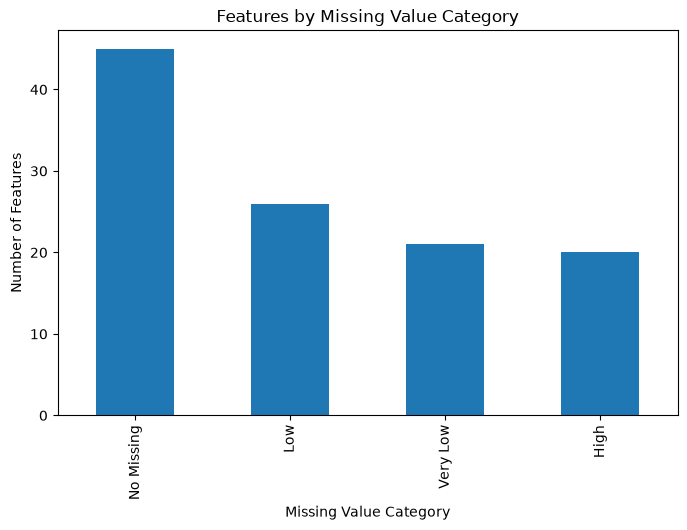

In [22]:
plt.figure(figsize=(8,5))

missing_df["Category"].value_counts().plot(
    kind="bar"
)

plt.title("Features by Missing Value Category")

plt.xlabel("Missing Value Category")

plt.ylabel("Number of Features")

plt.show()

Observation

The remaining dataset contains features with varying levels of missing values. While several variables contain little to no missing data, a smaller group of features exhibit moderate to high missing percentages.

Rather than applying a single imputation strategy, different techniques will be selected based on the nature of each feature and its business importance. 
This approach helps preserve useful information while reducing the risk of introducing bias into the predictive model.

Missing Value Treatment Strategy

Before applying any imputation technique, the missing features are reviewed from a business perspective.

Some variables contain missing values because the information was genuinely unavailable, while others are missing because the event has never occurred for a borrower. Treating both cases identically could introduce bias into the model.

Therefore, each feature will receive an individual treatment strategy before preprocessing is implemented.

In [23]:
treatment_strategy = {

    "desc": "Drop",

    "mths_since_last_record": "Investigate",

    "mths_since_recent_bc_dlq": "Investigate",

    "mths_since_last_major_derog": "Investigate",

    "mths_since_recent_revol_delinq": "Investigate",

    "il_util": "Investigate",

    "mths_since_rcnt_il": "Investigate",

    "all_util": "Investigate",

    "inq_last_12m": "Investigate",

    "total_cu_tl": "Investigate",

    "open_acc_6m": "Investigate",

    "open_il_24m": "Investigate",

    "inq_fi": "Investigate",

    "open_rv_12m": "Investigate",

    "total_bal_il": "Investigate",

    "open_rv_24m": "Investigate",

    "open_act_il": "Investigate",

    "max_bal_bc": "Investigate",

    "open_il_12m": "Investigate",

    "mths_since_last_delinq": "Investigate",

    "emp_title": "Unknown",

    "emp_length": "Mode",

    "mths_since_recent_inq": "Median",

    "num_tl_120dpd_2m": "Median",

    "mo_sin_old_il_acct": "Median"

}

In [24]:
missing_df["Treatment"] = (
    missing_df["Feature"]
    .map(treatment_strategy)
    .fillna("Keep")
)

missing_df.head(40)

,Feature,Missing Count,Missing Percentage,Category,Treatment
desc,desc,1221780,90.817730,High,Drop
mths_since_last_record,mths_since_last_record,1116755,83.010979,High,Investigate
mths_since_recent_bc_dlq,mths_since_recent_bc_dlq,1026290,76.286506,High,Investigate
mths_since_last_major_derog,mths_since_last_major_derog,991560,73.704945,High,Investigate
mths_since_recent_revol_delinq,mths_since_recent_revol_delinq,895348,66.553285,High,Investigate
il_util,il_util,880294,65.434287,High,Investigate
mths_since_rcnt_il,mths_since_rcnt_il,821928,61.095807,High,Investigate
all_util,all_util,807765,60.043038,High,Investigate
inq_last_12m,inq_last_12m,807713,60.039173,High,Investigate
total_cu_tl,total_cu_tl,807713,60.039173,High,Investigate


In [25]:
missing_df.to_csv(
    "../reports/missing_value_treatment_plan.csv",
    index=False
)

print("Treatment plan exported successfully.")

Treatment plan exported successfully.


In [26]:
missing_df["Treatment"].value_counts()

Treatment
Keep           87
Investigate    19
Median          3
Drop            1
Unknown         1
Mode            1
Name: count, dtype: int64

In [27]:
risk_df["emp_length"].value_counts(dropna=False)

emp_length
10+ years    442199
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
NaN           78511
6 years       62733
8 years       60701
7 years       59624
9 years       50937
Name: count, dtype: int64

In [28]:
(
    risk_df
    .groupby("emp_length")["target"]
    .mean()
    .sort_values()
)

emp_length
10+ years    0.187827
6 years      0.193519
7 years      0.194888
5 years      0.196010
4 years      0.197378
2 years      0.198073
9 years      0.199011
8 years      0.199338
3 years      0.199690
< 1 year     0.205273
1 year       0.205641
Name: target, dtype: float64

Employment Length Treatment

The `emp_length` feature contains approximately 5.8% missing values. An analysis of default rates across employment length categories shows only small variations between groups.

Since the missing percentage is relatively low and employment length is an important borrower characteristic, mode imputation has been selected as the treatment strategy.

In [29]:
emp_length_mode = risk_df["emp_length"].mode()[0]

print(emp_length_mode)

10+ years


In [30]:
risk_df["emp_length"] = risk_df["emp_length"].fillna(
    emp_length_mode
)

risk_df["emp_length"].isnull().sum()

np.int64(0)

In [31]:
risk_df["emp_length"].value_counts()

emp_length
10+ years    520710
2 years      121743
< 1 year     108061
3 years      107597
1 year        88494
5 years       84154
4 years       80556
6 years       62733
8 years       60701
7 years       59624
9 years       50937
Name: count, dtype: int64

In [32]:
print(
    "Missing values remaining:",
    risk_df["emp_length"].isnull().sum()
)

Missing values remaining: 0


In [33]:
missing_df.loc[
    missing_df["Feature"] == "emp_length",
    "Treatment"
] = "Mode Applied"

missing_df.head(30)

,Feature,Missing Count,Missing Percentage,Category,Treatment
desc,desc,1221780,90.817730,High,Drop
mths_since_last_record,mths_since_last_record,1116755,83.010979,High,Investigate
mths_since_recent_bc_dlq,mths_since_recent_bc_dlq,1026290,76.286506,High,Investigate
mths_since_last_major_derog,mths_since_last_major_derog,991560,73.704945,High,Investigate
mths_since_recent_revol_delinq,mths_since_recent_revol_delinq,895348,66.553285,High,Investigate
il_util,il_util,880294,65.434287,High,Investigate
mths_since_rcnt_il,mths_since_rcnt_il,821928,61.095807,High,Investigate
all_util,all_util,807765,60.043038,High,Investigate
inq_last_12m,inq_last_12m,807713,60.039173,High,Investigate
total_cu_tl,total_cu_tl,807713,60.039173,High,Investigate


In [34]:
missing_df.to_csv(
    "../reports/missing_value_treatment_plan.csv",
    index=False
)

Employment Title Treatment

The `emp_title` feature contains around 6.4% missing values. Since employment title is a categorical feature with thousands of unique values, replacing missing entries with the most frequent job title could introduce bias.

Instead, missing values are replaced with the category **"Unknown"**, preserving the information that the employment title was not available.

In [35]:
risk_df["emp_title"] = risk_df["emp_title"].fillna("Unknown")

print(
    "Missing values:",
    risk_df["emp_title"].isnull().sum()
)

Missing values: 0


In [36]:
missing_df.loc[
    missing_df["Feature"] == "emp_title",
    "Treatment"
] = "Unknown Applied"

In [37]:
median_features = [
    "mths_since_recent_inq",
    "num_tl_120dpd_2m",
    "mo_sin_old_il_acct"
]

for feature in median_features:

    median_value = risk_df[feature].median()

    risk_df[feature] = risk_df[feature].fillna(
        median_value
    )

    print(
        feature,
        "->",
        risk_df[feature].isnull().sum()
    )

mths_since_recent_inq -> 0
num_tl_120dpd_2m -> 0
mo_sin_old_il_acct -> 0


In [38]:
for feature in median_features:

    missing_df.loc[
        missing_df["Feature"] == feature,
        "Treatment"
    ] = "Median Applied"

In [39]:
missing_df.to_csv(
    "../reports/missing_value_treatment_plan.csv",
    index=False
)

Saving the Preprocessed Dataset

After completing the preprocessing steps, the cleaned dataset is saved locally. This dataset will be used as the input for feature engineering and subsequent modeling stages, avoiding repeated processing of the raw data.

In [40]:
risk_df.to_parquet(
    "../data/processed/credit_risk_cleaned.parquet",
    index=False
)

print("Preprocessed dataset saved successfully.")

Preprocessed dataset saved successfully.
